In [2]:
import builtins
print = builtins.print

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_table("data_from_the_back.txt")

Back sensor exploration notebook
Metrics computed:
 - Total Distance
 - HSR Time (> 6 km/h)
 - LSR Time (<= 6 km/h)
 - HSR Distance
 - LSR Distance
 - Max Speed
 - Average Speed (excluding near-zero speed)

 Assumption:
 We use WitMotion's provided SpeedX / SpeedY / SpeedZ-style columns
 to compute a scalar speed signal.

 Note:
 This is an MVP / exploration approach.
 Later we may replace this with a more controlled pipeline using
 acceleration + quaternions + gravity removal.

In [4]:
df.head()

,time,DeviceName,AccX(g),AccY(g),AccZ(g),AsX(°/s),AsY(°/s),AsZ(°/s),AngleX(°),AngleY(°),...,SpeedX(mm/s),SpeedY(mm/s),SpeedY(mm/s).1,Q0(),Q1(),Q2(),Q3(),Temperature(°C),Version(),Battery level(%)
0,2026-3-9 18:59:48.395,WT901BLE67(D94B4858716D),0.0,0.0,0.0,-3.601,1.953,0.61,110.19,-25.85,...,-141,-272,-233,0.27414,0.66217,0.46414,0.52039,24.8,10080.1.21,100
1,2026-3-9 18:59:48.515,WT901BLE67(D94B4858716D),0.0,0.0,0.0,-3.601,1.953,0.61,110.29,-25.89,...,-154,-263,-237,0.27414,0.66217,0.46414,0.52039,24.8,10080.1.21,100
2,2026-3-9 18:59:48.577,WT901BLE67(D94B4858716D),0.0,0.0,0.0,-3.601,1.953,0.61,110.53,-25.92,...,-161,-268,-247,0.27414,0.66217,0.46414,0.52039,24.8,10080.1.21,100
3,2026-3-9 18:59:48.637,WT901BLE67(D94B4858716D),0.0,0.0,0.0,-3.601,1.953,0.61,111.10,-26.02,...,-164,-289,-252,0.26129,0.66406,0.47269,0.51691,24.8,10080.1.21,100
4,2026-3-9 18:59:48.757,WT901BLE67(D94B4858716D),0.0,0.0,0.0,-3.601,1.953,0.61,111.80,-26.21,...,-172,-319,-268,0.26129,0.66406,0.47269,0.51691,24.8,10080.1.21,100


In [5]:
#This is important because WitMotion exports sometimes have strange or duplicated names.
print("Columns:")
for col in df.columns:
    print(col)

Columns:
time
DeviceName
AccX(g)
AccY(g)
AccZ(g)
AsX(°/s)
AsY(°/s)
AsZ(°/s)
AngleX(°)
AngleY(°)
AngleZ(°)
HX(uT)
HY(uT)
HZ(uT)
TrajectoryX(mm)
TrajectoryY(mm)
TrajectoryZ(mm)
SpeedX(mm/s)
SpeedY(mm/s)
SpeedY(mm/s).1
Q0()
Q1()
Q2()
Q3()
Temperature(°C)
Version()
Battery level(%)


We again have duplicated SpeedY, which actually should be SpeedZ presumably, let's fix this

In [6]:

def fix_speedY_duplicate_manual(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Step 1 — find all SpeedY-like columns
    speed_y_cols = [col for col in out.columns if "SpeedY(mm/s)" in col]

    print("Detected SpeedY-related columns:")
    for col in speed_y_cols:
        print(" -", col)

    if len(speed_y_cols) < 2:
        print("\nNo duplicate SpeedY columns found.")
        return out

    col1 = speed_y_cols[0]
    col2 = speed_y_cols[1]

    print("\nFirst few values comparison:")
    print(out[[col1, col2]].head(10))

    print("\nCorrelation between the two columns:")
    corr = out[col1].corr(out[col2])
    print(f"Correlation = {corr:.4f}")

    print("\nIf correlation is LOW → they are different axes (Y vs Z)")
    print("If correlation is HIGH → something is wrong")

    # Step 2 — rename second column to SpeedZ
    print(f"\nRenaming '{col2}' → 'SpeedZ(mm/s)'")
    out = out.rename(columns={col2: "SpeedZ(mm/s)"})

    return out

In [7]:
df = fix_speedY_duplicate_manual(df)

Detected SpeedY-related columns:
 - SpeedY(mm/s)
 - SpeedY(mm/s).1

First few values comparison:
   SpeedY(mm/s)  SpeedY(mm/s).1
0          -272            -233
1          -263            -237
2          -268            -247
3          -289            -252
4          -319            -268
5          -347            -283
6          -416            -297
7          -491             -61
8          -555             409
9          -376             568

Correlation between the two columns:
Correlation = -0.1249

If correlation is LOW → they are different axes (Y vs Z)
If correlation is HIGH → something is wrong

Renaming 'SpeedY(mm/s).1' → 'SpeedZ(mm/s)'


Now let's see the speed-related columns

In [8]:
def show_speed_columns(df: pd.DataFrame) -> list[str]:
    speed_cols = [col for col in df.columns if "Speed" in col]
    print("Speed-related columns found:")
    for col in speed_cols:
        print(" -", col)
    return speed_cols

In [9]:
show_speed_columns(df)

Speed-related columns found:
 - SpeedX(mm/s)
 - SpeedY(mm/s)
 - SpeedZ(mm/s)


['SpeedX(mm/s)', 'SpeedY(mm/s)', 'SpeedZ(mm/s)']

Let's inspect devices' name (if there is one device, this is just a check)

In [10]:
if "DeviceName" in df.columns:
    print(df["DeviceName"].value_counts())
else:
    print("No DeviceName column found.")

DeviceName
WT901BLE67(D94B4858716D)    1447
Name: count, dtype: int64


To prepare the data frame use this function:

optionally filters by device

parses time in datetime format

sorts by time

creates elapsed time t

computes row-to-row time delta dt

In [11]:
def prepare_sensor_df(
    df: pd.DataFrame,
    time_col: str = "time",
    device_col: str = "DeviceName",
    device_name: str | None = None,
) -> pd.DataFrame:
    out = df.copy()

    # Optional filtering by one device
    if device_name is not None and device_col in out.columns:
        out = out[out[device_col] == device_name].copy()

    # Parse time
    out[time_col] = pd.to_datetime(out[time_col])

    # Sort chronologically
    out = out.sort_values(time_col).reset_index(drop=True)

    # Time since start in seconds
    out["t"] = (out[time_col] - out[time_col].iloc[0]).dt.total_seconds()

    # Time between consecutive rows
    out["dt"] = out["t"].diff().fillna(0)

    return out

The function below adds necessary speed columns, also in better units

In [12]:
def add_speed_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds velocity components (m/s), speed magnitude (m/s), and speed in km/h.

    Assumes the following columns already exist and are correctly named:
    - SpeedX(mm/s)
    - SpeedY(mm/s)
    - SpeedZ(mm/s)
    """

    out = df.copy()

    # ---- Convert components: mm/s → m/s ----
    out["vx_m_s"] = out["SpeedX(mm/s)"] / 1000.0
    out["vy_m_s"] = out["SpeedY(mm/s)"] / 1000.0
    out["vz_m_s"] = out["SpeedZ(mm/s)"] / 1000.0

    # ---- Compute total speed magnitude ----
    out["speed_m_s"] = np.sqrt(
        out["vx_m_s"]**2 +
        out["vy_m_s"]**2 +
        out["vz_m_s"]**2
    )

    # ---- Convert to km/h ----
    out["speed_kmh"] = out["speed_m_s"] * 3.6

    return out

In [13]:
add_speed_columns(df).head()

,time,DeviceName,AccX(g),AccY(g),AccZ(g),AsX(°/s),AsY(°/s),AsZ(°/s),AngleX(°),AngleY(°),...,Q2(),Q3(),Temperature(°C),Version(),Battery level(%),vx_m_s,vy_m_s,vz_m_s,speed_m_s,speed_kmh
0,2026-3-9 18:59:48.395,WT901BLE67(D94B4858716D),0.0,0.0,0.0,-3.601,1.953,0.61,110.19,-25.85,...,0.46414,0.52039,24.8,10080.1.21,100,-0.141,-0.272,-0.233,0.384908,1.385668
1,2026-3-9 18:59:48.515,WT901BLE67(D94B4858716D),0.0,0.0,0.0,-3.601,1.953,0.61,110.29,-25.89,...,0.46414,0.52039,24.8,10080.1.21,100,-0.154,-0.263,-0.237,0.386075,1.389870
2,2026-3-9 18:59:48.577,WT901BLE67(D94B4858716D),0.0,0.0,0.0,-3.601,1.953,0.61,110.53,-25.92,...,0.46414,0.52039,24.8,10080.1.21,100,-0.161,-0.268,-0.247,0.398439,1.434382
3,2026-3-9 18:59:48.637,WT901BLE67(D94B4858716D),0.0,0.0,0.0,-3.601,1.953,0.61,111.10,-26.02,...,0.47269,0.51691,24.8,10080.1.21,100,-0.164,-0.289,-0.252,0.417038,1.501338
4,2026-3-9 18:59:48.757,WT901BLE67(D94B4858716D),0.0,0.0,0.0,-3.601,1.953,0.61,111.80,-26.21,...,0.47269,0.51691,24.8,10080.1.21,100,-0.172,-0.319,-0.268,0.450743,1.622674


## Trapezoidal Rule (Distance Estimation)

To compute distance from speed, we approximate the integral:

$$
d = \int v(t)\,dt
$$

Since our data is discrete, we use the **trapezoidal rule**, which assumes speed changes linearly between two samples:

$$
d_i = \frac{1}{2}(v_{i-1} + v_i)\cdot \Delta t
$$

This means we take the **average of consecutive speeds** and multiply by the time step.

---

### Implementation in code

```python
previous_speed = df["speed_m_s"].shift(1).fillna(df["speed_m_s"])
df["dist_m"] = 0.5 * (previous_speed + df["speed_m_s"]) * df["dt"]

In [14]:
def add_distance_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    previous_speed = out["speed_m_s"].shift(1).fillna(out["speed_m_s"])
    out["dist_m"] = 0.5 * (previous_speed + out["speed_m_s"]) * out["dt"]

    return out

The function below computes all the metrics except accelleration in one run

In [15]:
def compute_running_metrics(
    df: pd.DataFrame,
    hsr_threshold_kmh: float = 6.0,
    moving_speed_threshold_m_s: float = 0.1,
) -> dict:
    out = {}

    # Speed zones
    hsr_mask = df["speed_kmh"] > hsr_threshold_kmh
    lsr_mask = df["speed_kmh"] <= hsr_threshold_kmh

    # Moving mask for average speed
    moving_mask = df["speed_m_s"] > moving_speed_threshold_m_s

    # Core metrics
    out["Total Distance (m)"] = df["dist_m"].sum()
    out["HSR Time (s)"] = df.loc[hsr_mask, "dt"].sum()
    out["LSR Time (s)"] = df.loc[lsr_mask, "dt"].sum()
    out["HSR Distance (m)"] = df.loc[hsr_mask, "dist_m"].sum()
    out["LSR Distance (m)"] = df.loc[lsr_mask, "dist_m"].sum()
    out["Max Speed (km/h)"] = df["speed_kmh"].max()

    if moving_mask.sum() > 0:
        out["Average Speed (km/h)"] = df.loc[moving_mask, "speed_kmh"].mean()
    else:
        out["Average Speed (km/h)"] = 0.0

    return out

The function below runs the full pipeline

In [16]:
def run_full_analysis(
    df: pd.DataFrame,
    device_name: str | None = None,
) -> tuple[pd.DataFrame, dict]:
    """
    Runs the full processing pipeline:
    - prepares dataframe (time, dt, optional device filtering)
    - computes speed
    - computes distance
    - computes metrics

    Parameters
    ----------
    df : pd.DataFrame
        Raw dataframe
    device_name : str | None
        If provided, filters to that specific device

    Returns
    -------
    processed_df : pd.DataFrame
        Data with computed columns
    metrics : dict
        Dictionary of computed metrics
    """

    # Step 1 — prepare data (time + optional filtering)
    processed_df = prepare_sensor_df(df, device_name=device_name)

    # Step 2 — compute speed
    processed_df = add_speed_columns(processed_df)

    # Step 3 — compute distance
    processed_df = add_distance_columns(processed_df)

    # Step 4 — compute metrics
    metrics = compute_running_metrics(processed_df)

    return processed_df, metrics

Let's use the functions on the data and and see which results we get 

In [17]:
#adding pretty markdown to the jupyter notebook
from IPython.display import display, Markdown
print = lambda x: display(Markdown(str(x)))
#this function will pretty-print the metrics of the dataset
def display_metrics(metrics: dict) -> None:
    md = f"""
### 📊 Movement Metrics

- **Total Distance:** {metrics['Total Distance (m)']:.2f} m  
- **HSR Time (> 6 km/h):** {metrics['HSR Time (s)']:.2f} s  
- **LSR Time (≤ 6 km/h):** {metrics['LSR Time (s)']:.2f} s  

- **HSR Distance:** {metrics['HSR Distance (m)']:.2f} m  
- **LSR Distance:** {metrics['LSR Distance (m)']:.2f} m  

- **Max Speed:** {metrics['Max Speed (km/h)']:.2f} km/h  
- **Average Speed (moving):** {metrics['Average Speed (km/h)']:.2f} km/h  
"""
    display(Markdown(md))

import builtins
print = builtins.print

In [18]:
sensor_df, metrics = run_full_analysis(df)

display_metrics(metrics)


### 📊 Movement Metrics

- **Total Distance:** 2243.82 m  
- **HSR Time (> 6 km/h):** 142.35 s  
- **LSR Time (≤ 6 km/h):** 3.48 s  

- **HSR Distance:** 2240.06 m  
- **LSR Distance:** 3.76 m  

- **Max Speed:** 162.24 km/h  
- **Average Speed (moving):** 55.26 km/h  


Let's also do some plotting to see

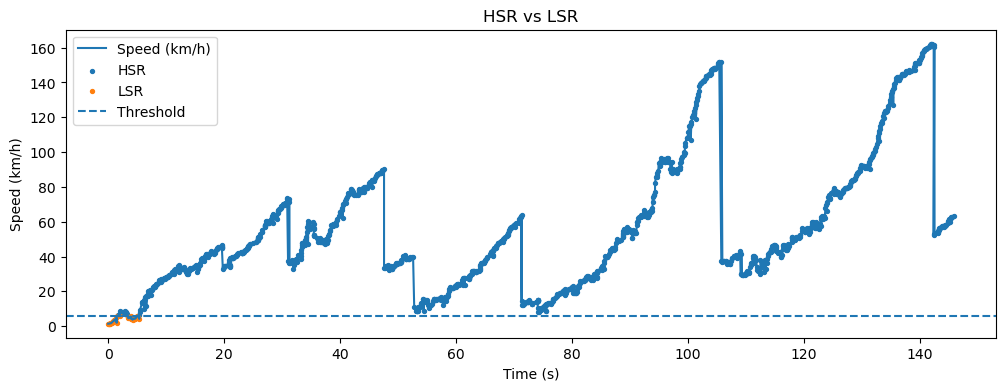

In [19]:
hsr_mask = sensor_df["speed_kmh"] > 6.0
lsr_mask = sensor_df["speed_kmh"] <= 6.0

plt.figure(figsize=(12, 4))
plt.plot(sensor_df["t"], sensor_df["speed_kmh"], label="Speed (km/h)")
plt.scatter(sensor_df.loc[hsr_mask, "t"], sensor_df.loc[hsr_mask, "speed_kmh"], s=8, label="HSR")
plt.scatter(sensor_df.loc[lsr_mask, "t"], sensor_df.loc[lsr_mask, "speed_kmh"], s=8, label="LSR")
plt.axhline(6.0, linestyle="--", label="Threshold")
plt.xlabel("Time (s)")
plt.ylabel("Speed (km/h)")
plt.title("HSR vs LSR")
plt.legend()
plt.show()

In [20]:
start_time = sensor_df["time"].min()
end_time = sensor_df["time"].max()
duration = end_time - start_time

start_time, end_time, duration

(Timestamp('2026-03-09 18:59:48.395000'),
 Timestamp('2026-03-09 19:02:14.220000'),
 Timedelta('0 days 00:02:25.825000'))